# 03 -- Symbolic Sudoku LP-M3N

## 0. Colab bootstrap (no-op locally)

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    import sys, os
    PROJECT_ROOT = '/content/drive/MyDrive/Master-thesis'
    if PROJECT_ROOT not in sys.path:
        sys.path.insert(0, PROJECT_ROOT)
    os.chdir(PROJECT_ROOT + '/notebooks')
    print('Colab setup done -- cwd:', os.getcwd())
except ImportError:
    print('Local run -- Colab bootstrap skipped')

Mounted at /content/drive
Colab setup done -- cwd: /content/drive/MyDrive/Master-thesis/notebooks


## 1. Setup

In [3]:
import json
import os
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'mnlearn').is_dir():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError('could not locate project root')
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)

from mnlearn.baselines import solve_batch
from mnlearn.config import load_config
from mnlearn.data import load_sudoku_benchmark
from mnlearn.experiments import collect_results
from mnlearn.learning import train

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RUN_TAG    = 'sudoku_sym_tightness'
RESULTS    = REPO_ROOT / 'results' / RUN_TAG
THESIS_FIG = REPO_ROOT / 'thesis' / 'figures' / RUN_TAG
THESIS_TBL = REPO_ROOT / 'thesis' / 'tables'
THESIS_FIG.mkdir(parents=True, exist_ok=True)
THESIS_TBL.mkdir(parents=True, exist_ok=True)

BASE_CONFIG = load_config(REPO_ROOT / 'configs' / 'experiments' / 'lpm3n_sudoku_symbolic.yaml')
print(f'DEVICE = {DEVICE}')

DEVICE = cuda


## 2. Lambda check (single seed, N=100)

N=100 is under-determined for Sudoku, so the regularizer has visible effect. Pick the best lambda here, then use it for the N sweep.

In [4]:
LAMBDA_CHECK_N    = 100
LAMBDA_CHECK_SEED = 0
LAMBDAS           = [1e-3, 5e-3, 1e-2, 5e-2]

def lambda_check_dir(wd):
    return RESULTS / f'lambda_check_n{LAMBDA_CHECK_N}_wd{wd:g}_seed{LAMBDA_CHECK_SEED}'

for wd in LAMBDAS:
    d = lambda_check_dir(wd)
    if (d / 'results.json').exists():
        print(f'skip: {d.name}')
        continue
    name = f'{RUN_TAG}/{d.name}'
    cfg = replace(
        BASE_CONFIG,
        experiment=replace(BASE_CONFIG.experiment, name=name, seed=LAMBDA_CHECK_SEED),
        data=replace(BASE_CONFIG.data, train_size=LAMBDA_CHECK_N),
        training=replace(BASE_CONFIG.training,
                         optimizer=replace(BASE_CONFIG.training.optimizer, weight_decay=wd)),
    )
    print(f'running: {name}')
    train(cfg)

print('\nlambda check done.')

running: sudoku_sym_tightness/lambda_check_n100_wd0.001_seed0
[run] sudoku_sym_tightness/lambda_check_n100_wd0.001_seed0  device=cuda  output=results/sudoku_sym_tightness/lambda_check_n100_wd0.001_seed0
  Epoch   1:  train_loss=230.0032  hamming=0.8891  zero_one=1.0000  phi_norm=0.5642
  Epoch   5:  train_loss=142.5848  hamming=0.8882  zero_one=1.0000  phi_norm=1.3339
  Epoch  10:  train_loss=69.8512  hamming=0.8900  zero_one=1.0000  phi_norm=1.6296
  Epoch  15:  train_loss=43.2299  hamming=0.8653  zero_one=1.0000  phi_norm=1.7331
  Epoch  20:  train_loss=30.1387  hamming=0.8141  zero_one=1.0000  phi_norm=1.6301
  Epoch  25:  train_loss=22.2857  hamming=0.7330  zero_one=1.0000  phi_norm=1.5209
  Epoch  30:  train_loss=17.8091  hamming=0.6657  zero_one=1.0000  phi_norm=1.4169
  Epoch  35:  train_loss=14.4934  hamming=0.5936  zero_one=1.0000  phi_norm=1.3106
  Epoch  40:  train_loss=11.9295  hamming=0.5659  zero_one=1.0000  phi_norm=1.2067
  Epoch  45:  train_loss=10.0319  hamming=0.5256

In [5]:
df_lc = collect_results(str(RESULTS / 'lambda_check_*/'))
df_lc = df_lc[df_lc['loss'] == 'lp_m3n'][['wd', 'hamming', 'zero_one']].sort_values('wd').reset_index(drop=True)
print(df_lc.to_string(index=False))

BEST_LAMBDA = float(df_lc.loc[df_lc['zero_one'].idxmin(), 'wd'])
print(f'\nBest lambda (lowest val 0/1 at N={LAMBDA_CHECK_N}): {BEST_LAMBDA:g}')

   wd  hamming  zero_one
0.001 0.000031    0.0002
0.005 0.000064    0.0004
0.010 0.000068    0.0003
0.050 0.000046    0.0004

Best lambda (lowest val 0/1 at N=100): 0.001


## 3. N sweep (3 seeds, best lambda)

In [6]:
N_VALUES = [100, 500, 1500, 5000]
SEEDS    = [0, 1, 2]

def n_sweep_dir(n, seed):
    return RESULTS / f'n_sweep_n{n}_wd{BEST_LAMBDA:g}_seed{seed}'

for seed in SEEDS:
    for n in N_VALUES:
        d = n_sweep_dir(n, seed)
        if (d / 'results.json').exists():
            print(f'skip: {d.name}')
            continue
        name = f'{RUN_TAG}/{d.name}'
        cfg = replace(
            BASE_CONFIG,
            experiment=replace(BASE_CONFIG.experiment, name=name, seed=seed),
            data=replace(BASE_CONFIG.data, train_size=n),
            training=replace(BASE_CONFIG.training,
                             optimizer=replace(BASE_CONFIG.training.optimizer, weight_decay=BEST_LAMBDA)),
        )
        print(f'running: {name}')
        train(cfg)

print('\nN sweep done.')

running: sudoku_sym_tightness/n_sweep_n100_wd0.001_seed0
[run] sudoku_sym_tightness/n_sweep_n100_wd0.001_seed0  device=cuda  output=results/sudoku_sym_tightness/n_sweep_n100_wd0.001_seed0
  Epoch   1:  train_loss=230.0032  hamming=0.8891  zero_one=1.0000  phi_norm=0.5642
  Epoch   5:  train_loss=142.5848  hamming=0.8882  zero_one=1.0000  phi_norm=1.3339
  Epoch  10:  train_loss=69.8512  hamming=0.8900  zero_one=1.0000  phi_norm=1.6296
  Epoch  15:  train_loss=43.2299  hamming=0.8653  zero_one=1.0000  phi_norm=1.7331
  Epoch  20:  train_loss=30.1387  hamming=0.8141  zero_one=1.0000  phi_norm=1.6301
  Epoch  25:  train_loss=22.2857  hamming=0.7330  zero_one=1.0000  phi_norm=1.5209
  Epoch  30:  train_loss=17.8091  hamming=0.6657  zero_one=1.0000  phi_norm=1.4169
  Epoch  35:  train_loss=14.4934  hamming=0.5936  zero_one=1.0000  phi_norm=1.3106
  Epoch  40:  train_loss=11.9295  hamming=0.5659  zero_one=1.0000  phi_norm=1.2067
  Epoch  45:  train_loss=10.0319  hamming=0.5256  zero_one=1.00

## 4. Solver oracle (0% floor)

In [7]:
N_TEST = BASE_CONFIG.data.test_size
bench  = load_sudoku_benchmark(str(REPO_ROOT / 'benchmarks' / 'sudoku'), mode='symbolic')
test_quizzes   = bench['test'].quizzes[:N_TEST].numpy()
test_solutions = bench['test'].solutions[:N_TEST].numpy()

solver_preds, feasible = solve_batch(test_quizzes)
solver_hamming  = float((solver_preds != test_solutions).mean())
solver_zero_one = float((~(solver_preds == test_solutions).all(axis=1)).mean())
print(f'solver hamming  = {solver_hamming:.4f}')
print(f'solver zero_one = {solver_zero_one:.4f}')
print(f'feasibility     = {feasible.mean():.4f}')

solver hamming  = 0.0000
solver zero_one = 0.0000
feasibility     = 1.0000


## 5. Headline table

Per-N mean +/- std for Hamming and 0/1, with solver floor

In [ ]:
df = collect_results(str(RESULTS / 'n_sweep_*/'))
df = df[df['loss'] == 'lp_m3n'].copy()
df = df[['n', 'seed', 'hamming', 'zero_one', 'best_epoch', 'final_epoch', 'total_seconds']]
df = df.sort_values(['n', 'seed']).reset_index(drop=True)
df.to_csv(THESIS_TBL / 's5_3_sudoku_sym_n_sweep.csv', index=False)

agg = (df.groupby('n')[['hamming', 'zero_one']]
         .agg(['mean', 'std', 'count']).reset_index())
agg.columns = ['_'.join([c for c in col if c]).rstrip('_') for col in agg.columns]

agg.loc[len(agg)] = {'n': 'solver oracle',
                      'hamming_mean': solver_hamming,  'hamming_std': 0.0,  'hamming_count': 1,
                      'zero_one_mean': solver_zero_one, 'zero_one_std': 0.0, 'zero_one_count': 1}

print(agg.to_string(index=False))
agg.to_csv(THESIS_TBL / 's5_3_sudoku_sym_tightness.csv', index=False)

                 n  hamming_mean  hamming_std  hamming_count  zero_one_mean  zero_one_std  zero_one_count
               100      0.000211     0.000330            3.0       0.001433      0.002223               3
               500      0.000036     0.000029            3.0       0.000233      0.000153               3
              1500      0.000010     0.000009            3.0       0.000067      0.000058               3
              5000      0.000012     0.000011            3.0       0.000067      0.000058               3
     solver oracle      0.000000     0.000000            1.0       0.000000      0.000000               1
Franc 2021 (N=500)           NaN          NaN            NaN       0.000000      0.000000               5


## 6. Learning curve

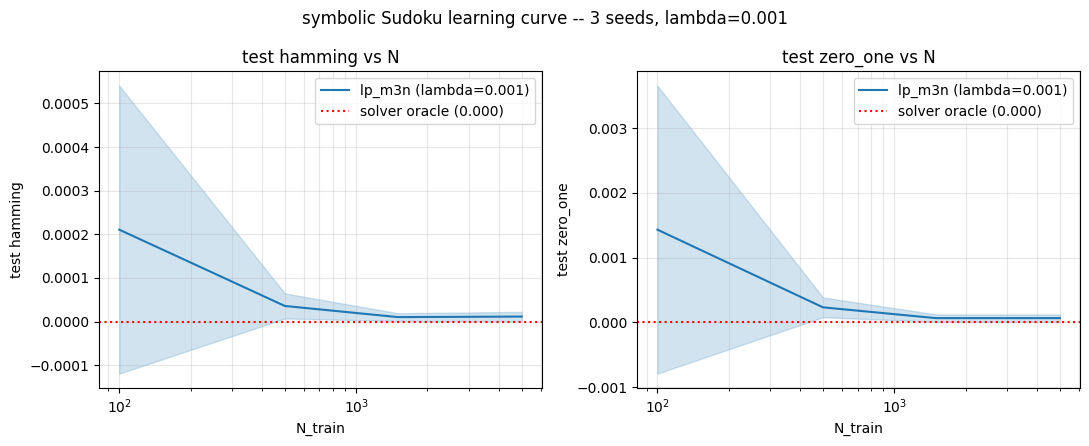

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, metric, floor in zip(axes, ('hamming', 'zero_one'), (solver_hamming, solver_zero_one)):
    g = (df.groupby('n')[metric].agg(['mean', 'std']).reset_index().sort_values('n'))
    line, = ax.plot(g['n'], g['mean'], label=f'lp_m3n (lambda={BEST_LAMBDA:g})')
    ax.fill_between(g['n'],
                    g['mean'] - g['std'].fillna(0.0),
                    g['mean'] + g['std'].fillna(0.0),
                    alpha=0.2, color=line.get_color())
    ax.axhline(floor, color='red', linestyle=':', label=f'solver oracle ({floor:.3f})')
    ax.set_xscale('log')
    ax.set_xlabel('N_train')
    ax.set_ylabel(f'test {metric}')
    ax.set_title(f'test {metric} vs N')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)

fig.suptitle(f'symbolic Sudoku learning curve -- {len(SEEDS)} seeds, lambda={BEST_LAMBDA:g}')
fig.tight_layout()
fig.savefig(THESIS_FIG / 'learning_curve.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Per-epoch trajectory (largest N, seed 0)

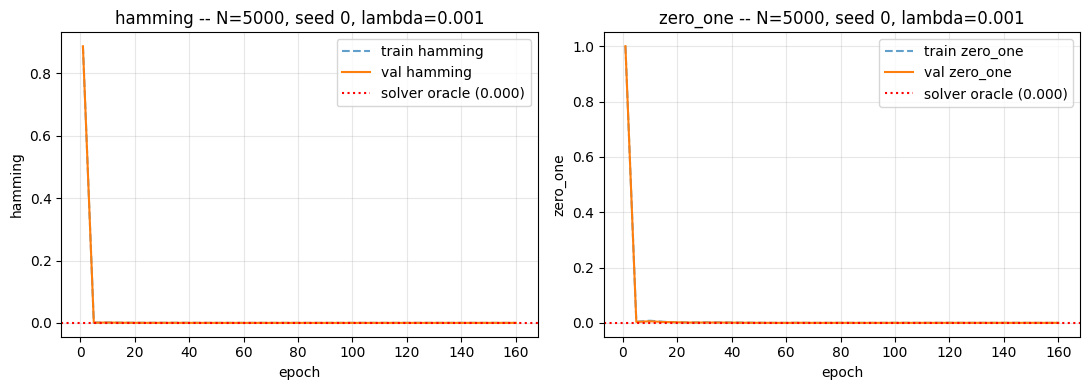

In [10]:
N_BIG = max(N_VALUES)
history = json.loads((n_sweep_dir(N_BIG, SEEDS[0]) / 'history.json').read_text())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric, floor in zip(axes, ('hamming', 'zero_one'), (solver_hamming, solver_zero_one)):
    train_m = [m[metric] for m in history['train_metrics']]
    val_m   = [m[metric] for m in history['val_metrics']]
    ax.plot(history['epoch'], train_m, linestyle='--', alpha=0.7, label=f'train {metric}')
    ax.plot(history['epoch'], val_m, label=f'val {metric}')
    ax.axhline(floor, color='red', linestyle=':', label=f'solver oracle ({floor:.3f})')
    ax.set_xlabel('epoch')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} -- N={N_BIG}, seed {SEEDS[0]}, lambda={BEST_LAMBDA:g}')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(THESIS_FIG / 'per_epoch.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Learned unary and pairwise scores

- **Unary** = `backbone.net.0.weight`, shape `[9, 9]`. Entry `[y, x]` is the score for predicting `y` when input is digit `x`. The 10th column (`?`) is the bias = score for a blank cell.
- **Pairwise** = `model.pairwise`, shape `[9, 9]`. Entry `[y_u, y_v]` is the edge-score for assignment `(y_u, y_v)`. Expect lower scores on the diagonal (penalty for `y_u = y_v`).

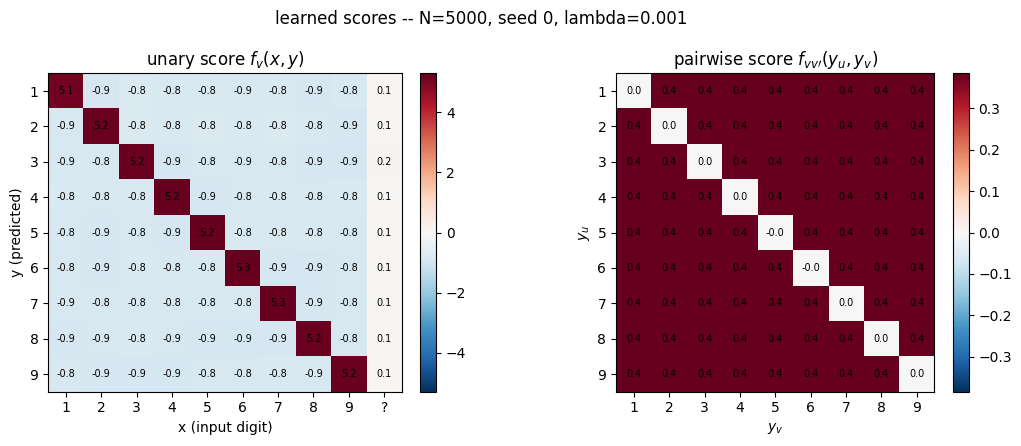

In [11]:
sd = torch.load(n_sweep_dir(N_BIG, SEEDS[0]) / 'model.pt', weights_only=True)
W_unary    = sd['backbone.net.0.weight'].cpu().numpy()
b_unary    = sd['backbone.net.0.bias'].cpu().numpy()
W_pairwise = sd['pairwise'].cpu().numpy()

unary_aug = np.column_stack([W_unary, b_unary])  # [9, 10] with bias as '?' column

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

vmax_u = float(np.abs(unary_aug).max())
im0 = axes[0].imshow(unary_aug, cmap='RdBu_r', vmin=-vmax_u, vmax=vmax_u)
for (i, j), v in np.ndenumerate(unary_aug):
    axes[0].text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=7)
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(list(range(1, 10)) + ['?'])
axes[0].set_yticks(range(9))
axes[0].set_yticklabels(range(1, 10))
axes[0].set_xlabel('x (input digit)')
axes[0].set_ylabel('y (predicted)')
axes[0].set_title('unary score $f_v(x, y)$')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

vmax_p = float(np.abs(W_pairwise).max())
im1 = axes[1].imshow(W_pairwise, cmap='RdBu_r', vmin=-vmax_p, vmax=vmax_p)
for (i, j), v in np.ndenumerate(W_pairwise):
    axes[1].text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=7)
axes[1].set_xticks(range(9))
axes[1].set_yticks(range(9))
axes[1].set_xticklabels(range(1, 10))
axes[1].set_yticklabels(range(1, 10))
axes[1].set_xlabel(r'$y_v$')
axes[1].set_ylabel(r'$y_u$')
axes[1].set_title(r'pairwise score $f_{vv\prime}(y_u, y_v)$')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

fig.suptitle(f'learned scores -- N={N_BIG}, seed {SEEDS[0]}, lambda={BEST_LAMBDA:g}')
fig.tight_layout()
fig.savefig(THESIS_FIG / 'learned_scores.png', bbox_inches='tight', dpi=150)
plt.show()